# Bernstein-Vazirani Algorithm

Problem: Given a black box function $f: \{0,1\}^n \to \{0,1\}$, where for an n-bit input string $x$, $f$ performs $a \cdot x \bmod 2$ for an unknown $n$-bit string $a$, find $a$. 

Unlike Deutsch-Jozsa for which the exponential speedup is only present against deterministic classical algorithms, even a bounded-error randomized classical algorithm requires at least $n$ black box queries to solve the problem, while BV does it in exactly one oracle query with probability 1.

In this notebook, I build the BV circuit and test it to recover the unknown bitstring of a random 3-bit function.

In [17]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
import random
from IPython.display import display

In [18]:
def make_oracle(a): #a is a bitstring
    def oracle(qc):
        n = len(a)
        bits = enumerate(a)
        for i, bit in bits:
            if bit == '1':
                qc.cx(i,n)
        return qc
    return oracle


In [19]:
def make_bv_circuit(n, oracle):
    qc = QuantumCircuit(n+1,n)
    qc.x(n) #for phase kickback
    for i in range(n+1):
        qc.h(i)
    oracle(qc)
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.measure(i,i)
    return qc

Bernstein-Vazirani Circuit for 010:


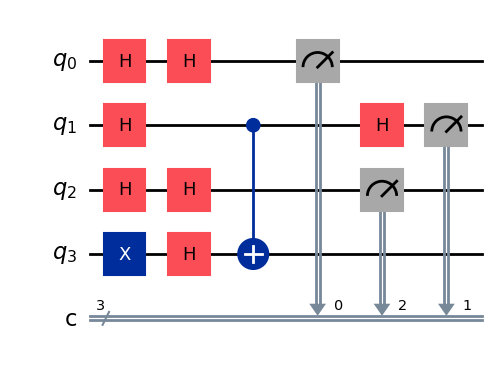

010
Correct


In [20]:
n = 3
unknown_bitstrings = ['000', '001', '010', '011', '100','101', '110', '111']
a = random.choice(unknown_bitstrings)
oracle = make_oracle(a)
circuit = make_bv_circuit(n, oracle)
print(f'Bernstein-Vazirani Circuit for {a}:')
display(circuit.draw('mpl'))
sampler = StatevectorSampler(default_shots=1000)
result = sampler.run([circuit]).result()
counts = result[0].data.c.get_counts()
outcome = list(counts.keys())[0] #deterministic outcome
print(outcome[::-1]) #accounting for Qiskit little-endian convention
if a == outcome[::-1]:
    print("Correct")
else:
    print("Incorrect")